In [1]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.io import loadmat

import pywt
import heartpy as hp

# A novel ternary pattern-based automatic psychiatric disorders classification using ECG signals

### OST: https://www.youtube.com/watch?v=uNMvABJFWHo

### Исследование: https://pmc.ncbi.nlm.nih.gov/articles/PMC10881455/

### Датасет: https://www.kaggle.com/datasets/buraktaci/Psychiatry-ECG

In [2]:
mat = loadmat(Path.cwd() / 'DATASETS' / 'Psychiatry ECG' / 'Bipolar' / '1_bi (4).mat')
print(mat.keys())

print(mat['sinyal'])

dict_keys(['__header__', '__version__', '__globals__', 'label', 'sinyal'])
[[  7.8   3.1  -4.7 ...  -6.6 -13.9 -11.1]
 [  7.6   3.2  -4.4 ...  -6.4 -13.8 -11. ]
 [  6.8   2.9  -3.9 ...  -6.4 -13.7 -10.9]
 ...
 [  9.5   5.1  -4.4 ...  -3.6 -10.5  -7.8]
 [  8.5   4.7  -3.8 ...  -3.7 -10.7  -8. ]
 [  8.2   4.6  -3.6 ...  -3.8 -10.9  -8.2]]


### Класс-обёртка для нашего датасета

Оригинальный код см. в "Psychiatry-ECG old.py"

In [3]:
def extract_number(filename):
    match = re.search(r'\((\d+)\)', str(filename)) # Напр.: supah_cool_file (4).mat
    if match:
        return int(match.group(1)) # Возвращаем найденное число как целое число
    return float('inf') # Если числа нет, ставим "бесконечность", чтобы такие файлы были в конце


class ECGDataset(torch.utils.data.Dataset):
    def __init__(self, path):
        self.path = path
        self.classes = [f.name for f in self.path.iterdir()]

        self.samples = { cls:
            sorted((self.path / cls).iterdir(), key=extract_number) for cls in self.classes
        }
        self.pinned_disorder = None

    # Что такое k??? Типа сколько у нас файлов в этом сэмпле?
    # def get_k(self, cls): 
    #     if cls in ['Bipolar', 'Schizophrenia']:
    #         return 13
    #     elif cls == 'Depression':
    #         return 11

    def set_disorder(self, disorder):
        assert disorder in list(self.samples.keys())
        self.pinned_disorder = disorder

    def __getitem__(self, idx):
        # Получаем сигнал одного конкретного пика;
        # Изначально тут получался какой-то диапаон пиков, но...
        # Почему 11? Почему 13? Чо то K??? Сложна нипанятна!!!11
        data_raw = loadmat(self.samples[self.pinned_disorder][idx])['sinyal']

        # k = self.get_k(self.pinned_disorder)
        # idx_range = [i for i in range(idx*k, idx*k+k)]
        # data_raw = loadmat(self.samples[self.pinned_disorder][idx_range[0]])['sinyal']
        # for i in range(1, len(idx_range)):
        #     signal = loadmat(self.samples[self.pinned_disorder][idx_range[i]])['sinyal']
        #     data_raw = np.append(data_raw, signal, axis=0)

        # Теперь разобъём этот сэмпл пика на отдельные каналы ЭКГ --
        # согласно исследованию, порядок каналов в датасете стандартный
        data_res = dict()
        for ch_idx, ch_label in enumerate([
            'Lead I', 'Lead II', 'Lead III',
            'Lead aVR', 'Lead aVF', 'Lead aVL',
            'Lead v1', 'Lead v2', 'Lead v3',
            'Lead v4', 'Lead v5', 'Lead v6'
        ]):
            data_ch = data_raw[:, ch_idx]
            data_res[ch_label] = data_ch

        return data_res
    
    def __len__(self):
        # k = self.get_k(self.pinned_disorder)
        # return len(list((self.path / self.pinned_disorder).iterdir())) // k
        return len(list((self.path / self.pinned_disorder).iterdir()))
    
    def visualize(self, start, end):
        for i in range(start, end+1):
            sample = self.__getitem__(i)
            labels = list(sample.keys())

            for j in range(4*3):
                plt.subplot(4, 3, j+1)
                plt.plot(sample[labels[j]], label=f'№{i} - {labels[j]}')
                plt.grid()
                plt.legend()

        plt.show()

In [4]:
dataset = ECGDataset(Path.cwd() / 'DATASETS' / 'Psychiatry ECG')

dataset

In [5]:
dataset.set_disorder('Depression')

dataset.classes

['Depression', 'Schizophrenia', 'Bipolar']

In [6]:
sample = dataset[6]
labels = list(sample.keys())

sample

{'Lead I': array([ 1.1,  1.1,  1. ,  0.8,  0.3,  0.2,  0.6,  0.8,  0.5,  0.5,  0.9,
         0.9,  0.6,  0.8,  0.6,  0.3,  0.4,  0.5,  0.6,  0.9,  1. ,  0.7,
         0.5,  0.1,  0. ,  0.2,  0.3,  0. ,  0.1,  0.7,  1. ,  0.7, -0.3,
        -0.1,  0.6,  0.1,  0.1,  0.3,  0.4,  0.2,  0.1,  0.3,  0.6,  0.5,
         0.4,  0.2,  0. ,  0. ,  0.2,  0.6,  0.7,  0.6,  0.5,  0.4,  0.2,
         0. , -0.1,  0.3,  0.3,  0.2,  0.8,  0.7,  0. ,  0.1,  0.3,  0. ,
        -0.2, -0.1,  0.1,  0.6,  0.7,  0.4,  0.4,  0.5,  0.1, -0.2,  0. ,
         0.6,  1. ,  0.8,  0.5,  0.9,  1. ,  0.6,  0.4,  0.1,  0.3,  0.7,
         0.6,  0.9,  0.8,  0.6,  0.6,  0.2,  0.1,  0.3,  0.5,  0.6,  0.6,
         0.7,  0.7,  0.6,  0.6,  0.3, -0.1,  0.1,  0.3,  0.4,  0.5,  0.5,
         0.7,  0.9,  0.7,  0.1,  0.2,  0.5,  0. ,  0.1,  0.2,  0.3,  0.9,
         0.8,  0.4,  0.1,  0.1,  0.8,  0.8,  0.1,  0.2,  0.5,  0.5,  0.7,
         0.5,  0.3,  0.5,  0.7,  0.6,  0.2,  0.5,  1. ,  0.7,  0.6,  0.6,
         0.6,  0.7,  0.1, -0

Визуализация данных поканально

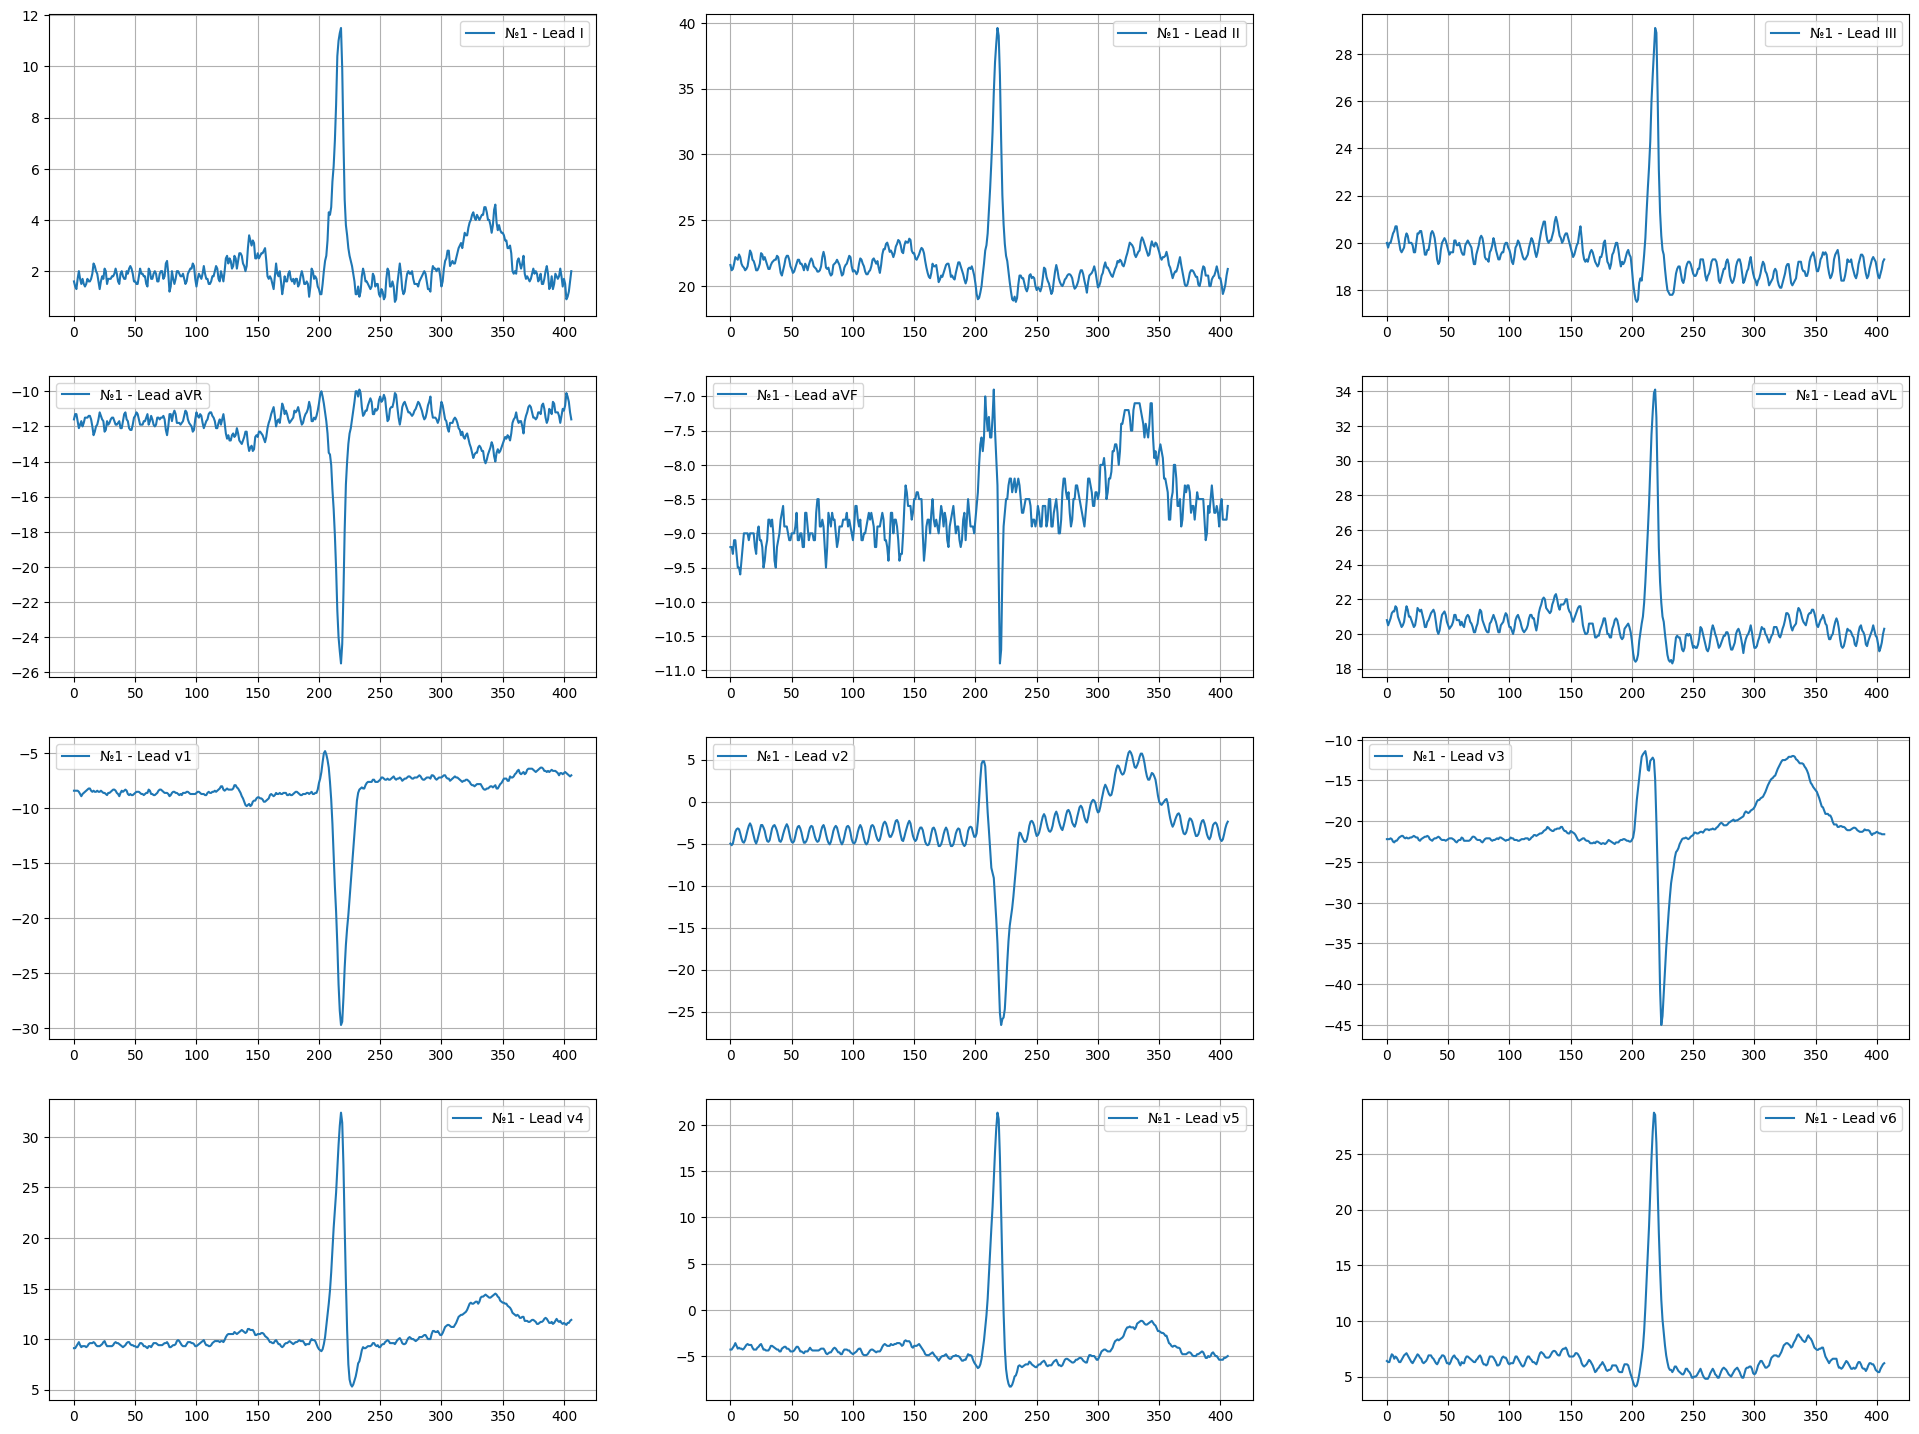

In [7]:
plt.figure(figsize=(24, 18))
dataset.visualize(1, 1)

### Обыкновенная депикизация

Как известно, весь датасет уже разделён на пики — что в принципе нам даже удобнее...

Но что, если нам для чего-то потребуется найти полные записи поцыэнта? К счастью, порядок записей после разделения на пики не был перемешан! Поэтому можно, проанализировав разрыв на краях каждого канала и выделив некоторый усреднённый порог, достаточно точно сказать, закончилась ли текущая запись или нет.

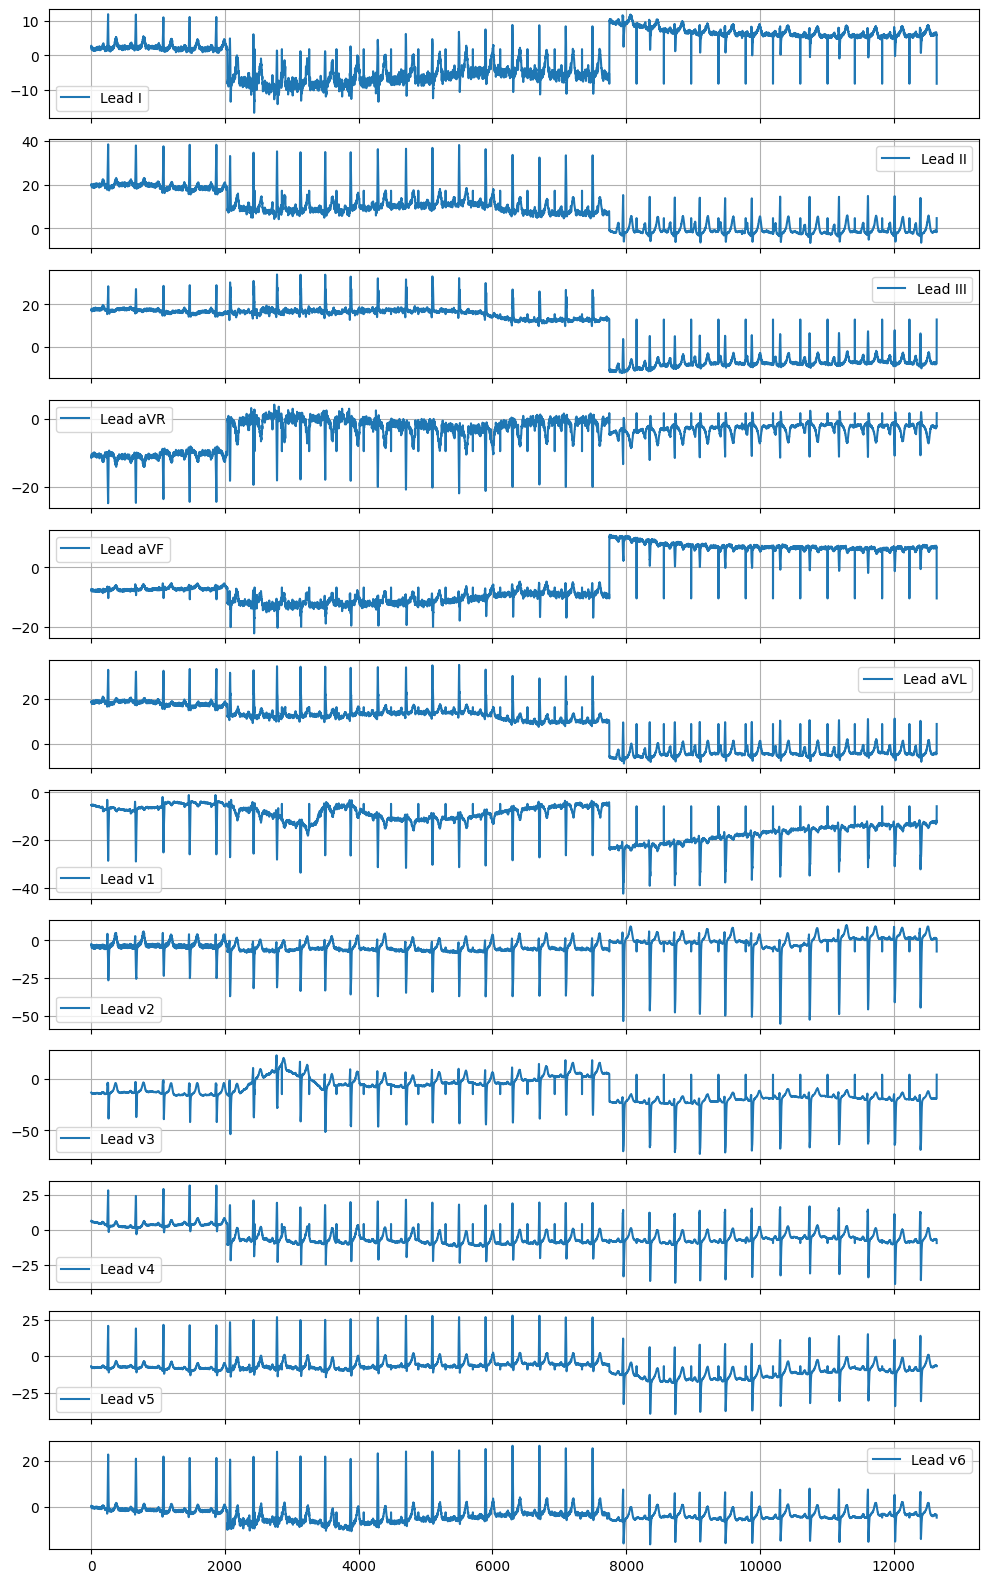

In [8]:
data_range_start = 10
data_range_step = 30
data_range = [dataset[i] for i in range(data_range_start, data_range_start+data_range_step+1)]

data_range_concat = {
    ch: np.concatenate([sample[ch] for sample in data_range], axis=0) for ch in labels
}

fig, axes = plt.subplots(len(labels), 1, figsize=(12, 20), sharex=True)
time = np.arange(data_range_concat[labels[0]].shape[0])

for ax, ch in zip(axes, labels):
    ax.plot(time, data_range_concat[ch], label=ch)
    ax.legend()
    ax.grid()
# plt.xlim(400, 410)

plt.show()

Именно это мы сейчас и сделаем...

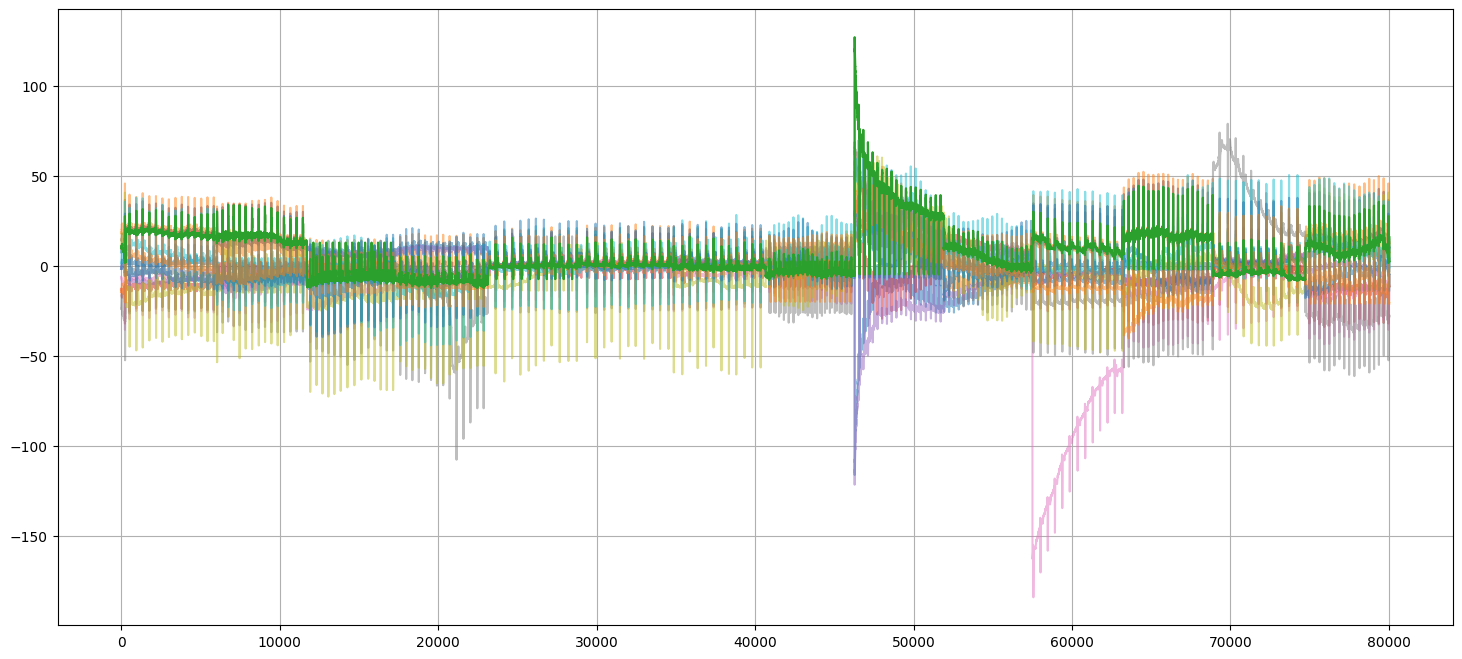

In [9]:
data = [dataset[i] for i in range(len(dataset))]

data_concat = {
    ch: np.concatenate([sample[ch] for sample in data], axis=0) for ch in labels
}


# господь_покинул_этот_мир.jpg
# ch_avg = np.sum(list([data_concat[ch] / len(labels) for ch in labels]), axis=0)

plt.figure(figsize=(18, 8))
for label in labels:
    plt.plot(data_concat[label], alpha=0.5)

plt.plot(data_concat['Lead III']) # По этому каналу лучше всего видно разрывы между записями

plt.grid()
plt.show()

Вейвлет Де Боша ~~(нет блин фильтр резни)~~ взят из preproc.ipynb

In [10]:
def denoise_ppg(ppg_signal, wavelet='db2', level=2, threshold_factor=1.5):
    coeffs = pywt.wavedec(ppg_signal, wavelet, level=level)

    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = threshold_factor * sigma

    coeffs_thresholded = [pywt.threshold(c, threshold, mode='soft') for c in coeffs]

    denoised_signal = pywt.waverec(coeffs_thresholded, wavelet)
    denoised_signal = denoised_signal[:len(ppg_signal)]

    return denoised_signal

data_filtered = [
    { label: denoise_ppg(data[i][label], 'db5', 10, 5) for label in labels }
    for i in range(len(dataset))
]

data_filtered_concat = {
    ch: np.concatenate([sample[ch] for sample in data_filtered], axis=0) for ch in labels
}


deltas_threshold = 3.0  

rec_slices = [
    slice(-9999, 0) # Временное значение, чтобы не было ошибки
]

for i in range(len(dataset) - 1):
    deltas_mean = 0

    for label in labels:
        delta = np.abs(
            np.median(np.abs(data_filtered[i][label])) - np.median(np.abs(data_filtered[i+1][label]))
            # data[i][label][-1] - data[i+1][label][0]
        )
        deltas_mean += delta / len(labels)
    print(f'Средняя дельта между №{i} и №{i+1} -- {deltas_mean}')

    if (deltas_mean > deltas_threshold) or (i == len(dataset) - 2):
        rec_slices.append(
            slice(rec_slices[-1].stop, i+2)
        )

rec_slices.pop(0) # Удаляем временное значение

print('\nПредположительные отрезки записей: ' + str(rec_slices))

Средняя дельта между №0 и №1 -- 7.911061308867566
Средняя дельта между №1 и №2 -- 0.8546401341203091
Средняя дельта между №2 и №3 -- 0.5352330854794012
Средняя дельта между №3 и №4 -- 0.7577940676082502
Средняя дельта между №4 и №5 -- 0.6919563578463244
Средняя дельта между №5 и №6 -- 0.5408133996043443
Средняя дельта между №6 и №7 -- 0.6734449185689322
Средняя дельта между №7 и №8 -- 0.8150997753022333
Средняя дельта между №8 и №9 -- 0.4092366394400594
Средняя дельта между №9 и №10 -- 0.6816490117554515
Средняя дельта между №10 и №11 -- 0.5971791870903138
Средняя дельта между №11 и №12 -- 0.5041233661578444
Средняя дельта между №12 и №13 -- 0.8831288001610822
Средняя дельта между №13 и №14 -- 0.04050448519717693
Средняя дельта между №14 и №15 -- 4.274422056460756
Средняя дельта между №15 и №16 -- 1.150063930020479
Средняя дельта между №16 и №17 -- 0.8060735245504916
Средняя дельта между №17 и №18 -- 0.8153348080274748
Средняя дельта между №18 и №19 -- 0.6150331737186397
Средняя дельта

Посмотрим, что получилось... нутакое

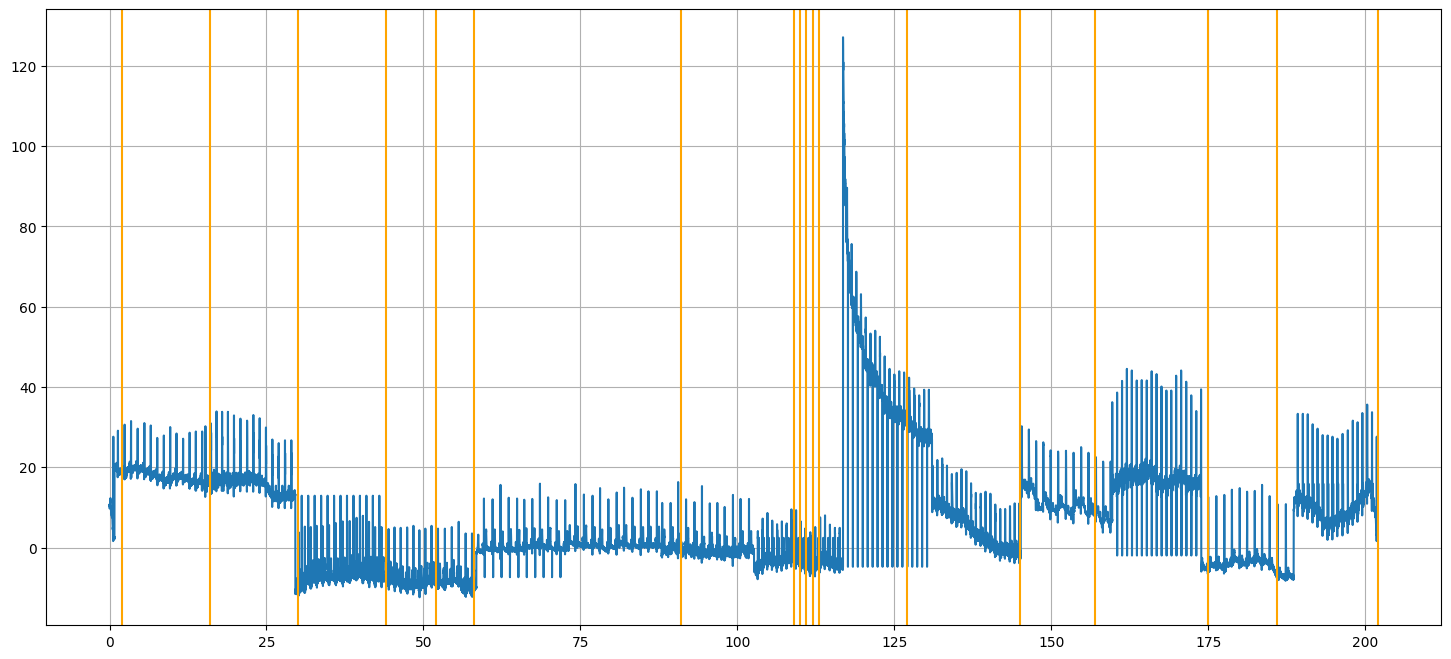

In [11]:
plt.figure(figsize=(18, 8))
plt.plot(np.arange(0, len(dataset), len(dataset) / len(data_concat['Lead III'])), data_concat['Lead III'])

for rs in rec_slices:
    plt.axvline(rs.stop, color='orange')

plt.grid()
plt.show()

В отчании я решил попробовать разбить сигналы константами, чтобы возможно увидеть какие-то взаимосвязи… и обаружил, что длины каждой из записей в полностью сконкатенированном датасете равны, просто имеют немноого разные смещение и длину в зависимости от типа расстройства!!

Абсолютно верного значения, конечно же, не существует, но для устранения всех погрешностей достаточно вырезать все те пики, на которые приходится разделение записи.

13.150648723257419


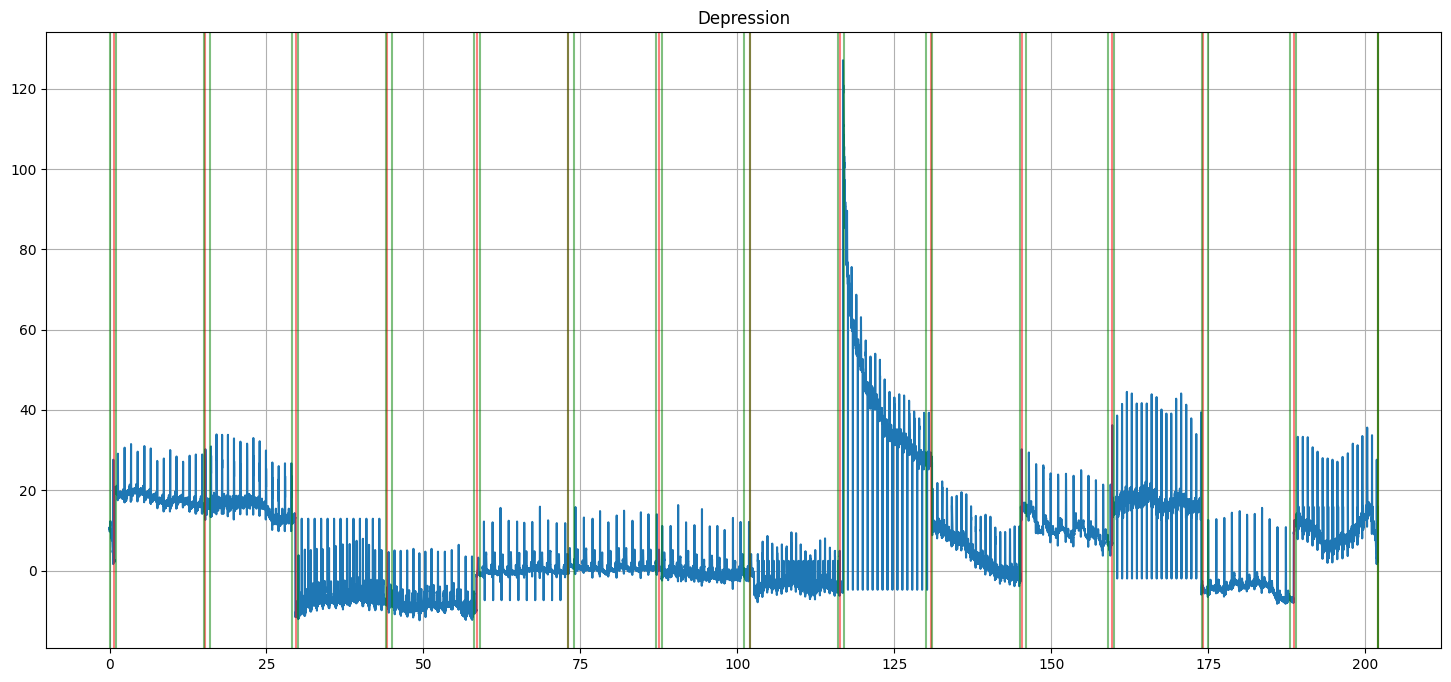

In [12]:
podbor = []


if dataset.pinned_disorder == 'Depression':
    print(len(dataset) / 14.49 - 0.79)
    podbor.append(0.79)
elif dataset.pinned_disorder == 'Schizophrenia':
    print(len(dataset) / 14.263 - 12.461)
    # podbor.append(12.461)
elif dataset.pinned_disorder == 'Bipolar':
    print(len(dataset) / 15.25 - 0.97)
    podbor.append(0.97)

while podbor[-1] < len(dataset):
    if dataset.pinned_disorder == 'Depression':
        podbor.append(podbor[-1] + 14.45)
    elif dataset.pinned_disorder == 'Schizophrenia':
        podbor.append(podbor[-1] + 14.263)
    elif dataset.pinned_disorder == 'Bipolar':
        podbor.append(podbor[-1] + 15.25)

# Исправляем последний пик, чтобы в slice он лежал ровно на конце данных
podbor[-1] = float(np.floor(len(dataset)))


plt.figure(figsize=(18, 8))
plt.plot(np.arange(0, len(dataset), len(dataset) / len(data_concat['Lead III'])), data_concat['Lead III'])
for abobus in podbor:
    plt.axvline(abobus, color='red', alpha=0.5)
    plt.axvline(np.ceil(abobus), color='green', alpha=0.5)
    plt.axvline(np.floor(abobus), color='green', alpha=0.5)

# plt.xlim(0, 20)
plt.title(dataset.pinned_disorder)
plt.grid()
plt.show()

### Наконец, скормим наши данные в HeartPy

На это момент мой мозг потихоньку нчал плавиться, потому код тоже деградировать малясь)))

In [13]:
# b, a = butter_bandpass(0.5, 10, 256)
# filtered_signal = filtfilt(b, a, ppg_example_finger)

# wd, m = hp.process(
#     filtered_signal,
#     sample_rate=256
# )

# hp.plotter(wd, m)
# plt.show()

# for measure in m.keys():
#     print('%s: %f' %(measure, m[measure]))

In [14]:
data_slices = [slice(
        int(np.ceil(podbor[i]) / len(dataset) * len(data_concat['Lead III'])),
        int(np.floor(podbor[i+1]) / len(dataset) * len(data_concat['Lead III']))
    ) for i in range(1, len(podbor) - 1)
]

print('\nОтрезки записей в данных (с обрезанными концами): ' + str(data_slices))


Отрезки записей в данных (с обрезанными концами): [slice(6338, 11488, None), slice(11884, 17431, None), slice(17827, 22977, None), slice(23373, 28919, None), slice(29316, 34466, None), slice(34862, 40012, None), slice(40408, 45954, None), slice(46351, 51501, None), slice(51897, 57443, None), slice(57839, 62989, None), slice(63386, 68932, None), slice(69328, 74478, None), slice(74874, 80025, None)]


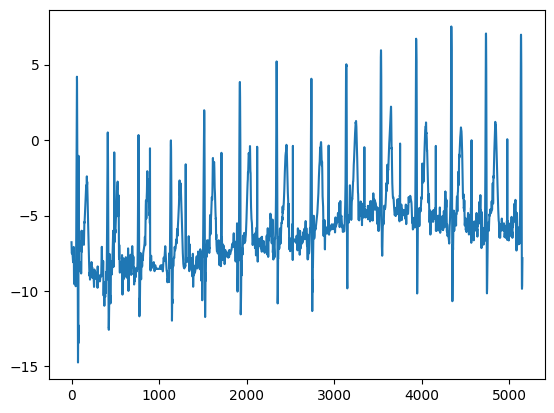

BadSignalWarning: 
----------------
Could not determine best fit for given signal. Please check the source signal.
 Probable causes:
- detected heart rate falls outside of bpmmin<->bpmmax constraints
- no detectable heart rate present in signal
- very noisy signal (consider filtering and scaling)
If you're sure the signal contains heartrate data, consider filtering and/or scaling first.
----------------


In [15]:
for slice in data_slices:
    for label in labels:
        plt.plot(data_filtered_concat[label][slice])
        # plt.xlim(0, 200)
        plt.show()

        wd, m = hp.process(
            data_filtered_concat[label][slice],
            sample_rate=5000
        )

hp.plotter(wd, m)
plt.show()

for measure in m.keys():
    print('%s: %f' %(measure, m[measure]))

На этом прекрасном моменте, когда heartpy в очередной раз выдаёт ошибку "ваше ЭКГ не ЭКГ!!1" и хрен ты что ему по этому поводу сделаешь, я умываю руки. Может помочь бахнуть ещё фильтрации или даунскейлинг, но это не точно. <!-- Да и вообще пойду-ка я помоюсь, жарко капец XD -->